# 03 - Classificação e Avaliação

**Cenário A — Inspeção de frutas (maçãs frescas vs podres)**

Vamos:

1. Carregar `X.csv` / `y.csv`
2. Fazer split **train / validation / test** estratificado
3. Padronizar features (`StandardScaler` ajustado **apenas no train**, evitando vazamento)
4. Treinar e comparar **dois classificadores clássicos**: `RandomForestClassifier` e `SVC`
   (com validação cruzada simples no treino para ajuste leve de hiperparâmetros)
5. Avaliar no conjunto de teste: acurácia, precisão, recall, F1, matriz de confusão e curva ROC
6. Tabela comparativa final
7. Análise de erros (exemplos em que os modelos erraram)

Todos os `random_state` estão fixados em **42** para reprodutibilidade.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, auc, classification_report)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

X = pd.read_csv("../X.csv")
y_raw = pd.read_csv("../y.csv")["classe"]

le = LabelEncoder()
y = le.fit_transform(y_raw)  # fresh=0, rotten=1 (ordem alfabética)
print("Classes:", dict(zip(le.classes_, le.transform(le.classes_))))
print(f"X shape: {X.shape}, y shape: {y.shape}")

Classes: {'fresh': np.int64(0), 'rotten': np.int64(1)}
X shape: (600, 39), y shape: (600,)


## 3.1 Split estratificado: train / validation / test

- 60% treino, 20% validação, 20% teste
- Estratificado para manter a mesma proporção fresh/rotten em cada conjunto

In [3]:
# primeiro separa teste (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# depois separa validação (20% do total = 25% do que restou)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=RANDOM_STATE
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Validação: {X_val.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

for nome, yy in [("treino", y_train), ("validação", y_val), ("teste", y_test)]:
    prop = np.bincount(yy) / len(yy)
    print(f"  Proporção {nome}: fresh={prop[0]:.2f}, rotten={prop[1]:.2f}")

Treino: 360 amostras
Validação: 120 amostras
Teste: 120 amostras
  Proporção treino: fresh=0.50, rotten=0.50
  Proporção validação: fresh=0.50, rotten=0.50
  Proporção teste: fresh=0.50, rotten=0.50


## 3.2 Padronização (StandardScaler)

**Importante**: o `scaler` é ajustado (`fit`) apenas com `X_train`, e depois aplicado (`transform`) em validação e teste — isso evita vazamento de dados.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaler ajustado apenas em X_train. Médias (deve ser ~0):", X_train_scaled.mean(axis=0)[:3].round(3))

Scaler ajustado apenas em X_train. Médias (deve ser ~0): [ 0.  0. -0.]


## 3.3 Modelo 1: Random Forest

Ajuste leve de hiperparâmetros via `GridSearchCV` com validação cruzada estratificada (5 folds) no conjunto de treino.

In [5]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_param_grid, cv=cv, scoring="f1", n_jobs=1
)
rf_grid.fit(X_train_scaled, y_train)

print("Melhores parâmetros (RF):", rf_grid.best_params_)
print(f"Melhor F1 (CV): {rf_grid.best_score_:.4f}")

rf_model = rf_grid.best_estimator_

# desempenho na validação
y_val_pred_rf = rf_model.predict(X_val_scaled)
print(f"F1 validação (RF): {f1_score(y_val, y_val_pred_rf):.4f}")

Melhores parâmetros (RF): {'max_depth': None, 'n_estimators': 200}
Melhor F1 (CV): 0.9559
F1 validação (RF): 0.9833


## 3.4 Modelo 2: SVM (SVC)

Mesmo procedimento: GridSearchCV com validação cruzada no treino.

In [6]:
svm_param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["rbf", "linear"],
    "gamma": ["scale", "auto"],
}

svm_grid = GridSearchCV(
    SVC(probability=True, random_state=RANDOM_STATE),
    svm_param_grid, cv=cv, scoring="f1", n_jobs=1
)
svm_grid.fit(X_train_scaled, y_train)

print("Melhores parâmetros (SVM):", svm_grid.best_params_)
print(f"Melhor F1 (CV): {svm_grid.best_score_:.4f}")

svm_model = svm_grid.best_estimator_

y_val_pred_svm = svm_model.predict(X_val_scaled)
print(f"F1 validação (SVM): {f1_score(y_val, y_val_pred_svm):.4f}")

c:\Users\gomes\Downloads\projeto_inspecao_frutas\projeto\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\gomes\Downloads\projeto_inspecao_frutas\projeto\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\gomes\Downloads\projeto_inspecao_frutas\projeto\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\gomes\Downloads\projeto_inspecao_frutas\projeto\.ven

Melhores parâmetros (SVM): {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Melhor F1 (CV): 0.9545
F1 validação (SVM): 0.9917


c:\Users\gomes\Downloads\projeto_inspecao_frutas\projeto\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\gomes\Downloads\projeto_inspecao_frutas\projeto\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


## 3.5 Avaliação final no conjunto de TESTE

Agora treinamos os modelos finais com `train + validation` (para usar mais dados) mantendo os hiperparâmetros escolhidos, e avaliamos **uma única vez** no conjunto de teste, que não foi usado em nenhuma etapa anterior.

In [7]:
# combina treino + validação para o treino final (hiperparâmetros já escolhidos)
X_trainval_scaled = np.vstack([X_train_scaled, X_val_scaled])
y_trainval = np.concatenate([y_train, y_val])

rf_final = RandomForestClassifier(**rf_grid.best_params_, random_state=RANDOM_STATE)
rf_final.fit(X_trainval_scaled, y_trainval)

svm_final = SVC(**svm_grid.best_params_, probability=True, random_state=RANDOM_STATE)
svm_final.fit(X_trainval_scaled, y_trainval)

modelos = {
    "Random Forest": rf_final,
    "SVM": svm_final,
}

resultados = []
y_preds = {}
y_probas = {}

for nome, modelo in modelos.items():
    y_pred = modelo.predict(X_test_scaled)
    y_proba = modelo.predict_proba(X_test_scaled)[:, 1]
    y_preds[nome] = y_pred
    y_probas[nome] = y_proba

    resultados.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
    })

tabela_resultados = pd.DataFrame(resultados).set_index("Modelo").round(4)
tabela_resultados.to_csv("../outputs/tabelas/tabela_metricas.csv")
tabela_resultados

c:\Users\gomes\Downloads\projeto_inspecao_frutas\projeto\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Acurácia,Precisão,Recall,F1-score
Modelo,,,,
Random Forest,0.975,0.9672,0.9833,0.9752
SVM,0.975,0.9672,0.9833,0.9752


## 3.6 Matrizes de confusão

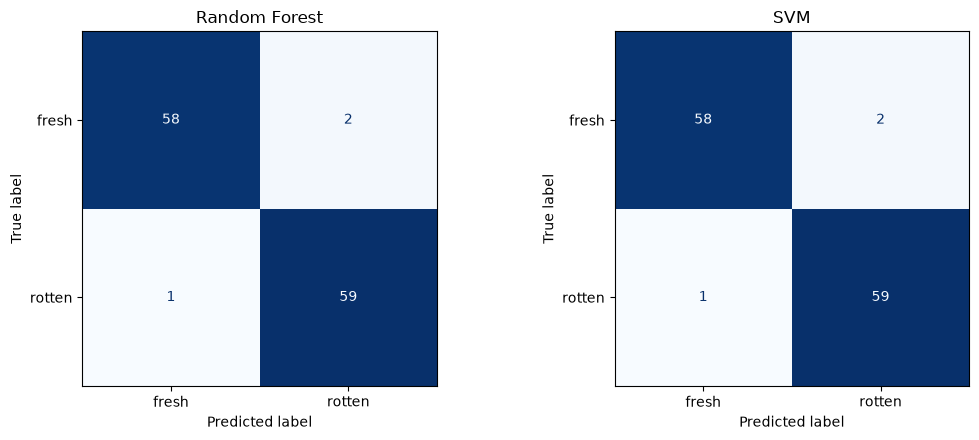

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (nome, modelo) in zip(axes, modelos.items()):
    cm = confusion_matrix(y_test, y_preds[nome])
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nome)

plt.tight_layout()
plt.savefig("../outputs/matrizes/matrizes_confusao.png", dpi=120, bbox_inches="tight")
plt.show()

## 3.7 Curva ROC (caso binário)

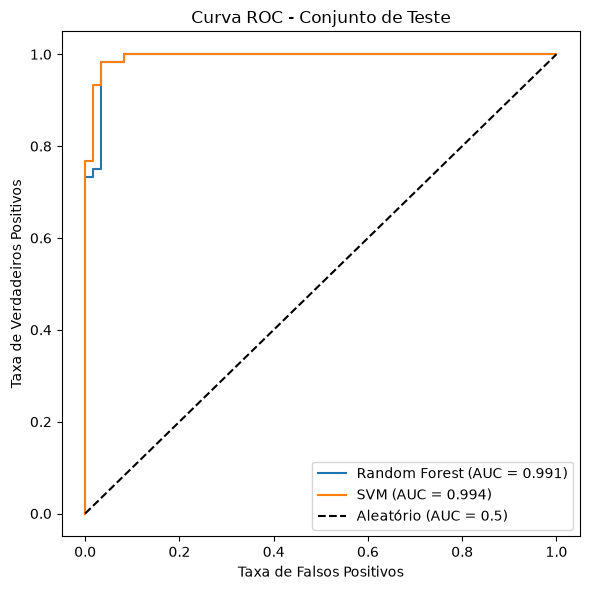

In [9]:
plt.figure(figsize=(6, 6))

for nome in modelos:
    fpr, tpr, _ = roc_curve(y_test, y_probas[nome])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{nome} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Aleatório (AUC = 0.5)")
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC - Conjunto de Teste")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figuras/curva_roc.png", dpi=120, bbox_inches="tight")
plt.show()

## 3.8 Importância de variáveis (Random Forest)

Análise extra de seleção/interpretação de features: quais features mais contribuíram para as decisões do Random Forest.

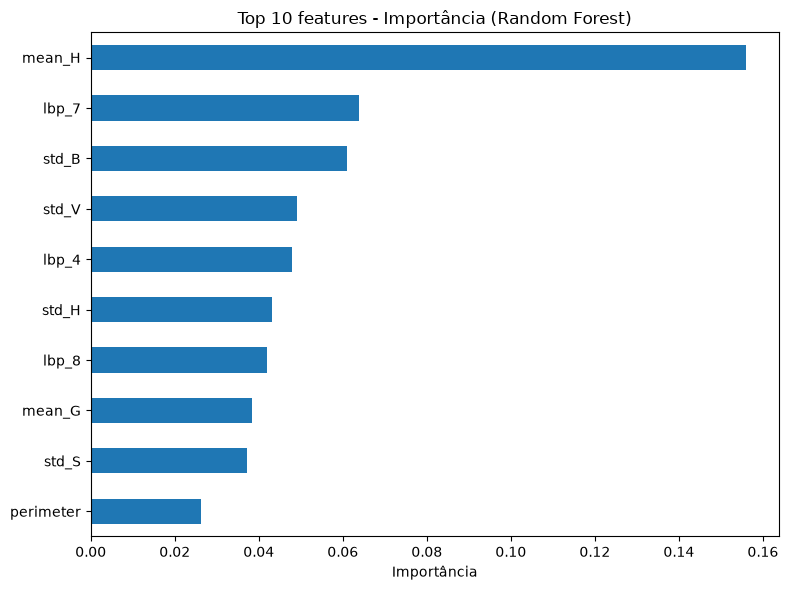

mean_H       0.156034
lbp_7        0.063821
std_B        0.061013
std_V        0.049075
lbp_4        0.047793
std_H        0.043097
lbp_8        0.041891
mean_G       0.038426
std_S        0.037115
perimeter    0.026238
dtype: float64

In [10]:
importancias = pd.Series(rf_final.feature_importances_, index=X.columns)
importancias_top = importancias.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
importancias_top.sort_values().plot(kind="barh")
plt.title("Top 10 features - Importância (Random Forest)")
plt.xlabel("Importância")
plt.tight_layout()
plt.savefig("../outputs/figuras/importancia_features.png", dpi=120, bbox_inches="tight")
plt.show()

importancias_top

## 3.9 Análise de erros

Vamos identificar as imagens de teste em que o melhor modelo errou e visualizá-las.

In [11]:
# recupera nomes de arquivo correspondentes ao conjunto de teste
df_completo = pd.read_csv("../X.csv")
df_completo["classe"] = pd.read_csv("../y.csv")["classe"]

# refaz os mesmos splits com os índices originais para rastrear arquivos
import glob
DATASET_DIR = "../dataset"
CLASSES = ["fresh", "rotten"]
paths_all, labels_all = [], []
for cls in CLASSES:
    files = sorted(glob.glob(os.path.join(DATASET_DIR, cls, "*.png")))
    paths_all += files
    labels_all += [cls] * len(files)

idx_all = np.arange(len(paths_all))
idx_train_val, idx_test = train_test_split(idx_all, test_size=0.2, stratify=labels_all, random_state=RANDOM_STATE)

paths_test = [paths_all[i] for i in idx_test]

# escolhe o modelo com melhor F1 para análise de erros
melhor_modelo_nome = tabela_resultados["F1-score"].idxmax()
print(f"Melhor modelo (F1): {melhor_modelo_nome}")

y_pred_melhor = y_preds[melhor_modelo_nome]
erros_idx = np.where(y_pred_melhor != y_test)[0]
print(f"Total de erros no teste ({melhor_modelo_nome}): {len(erros_idx)} de {len(y_test)}")

Melhor modelo (F1): Random Forest
Total de erros no teste (Random Forest): 3 de 120


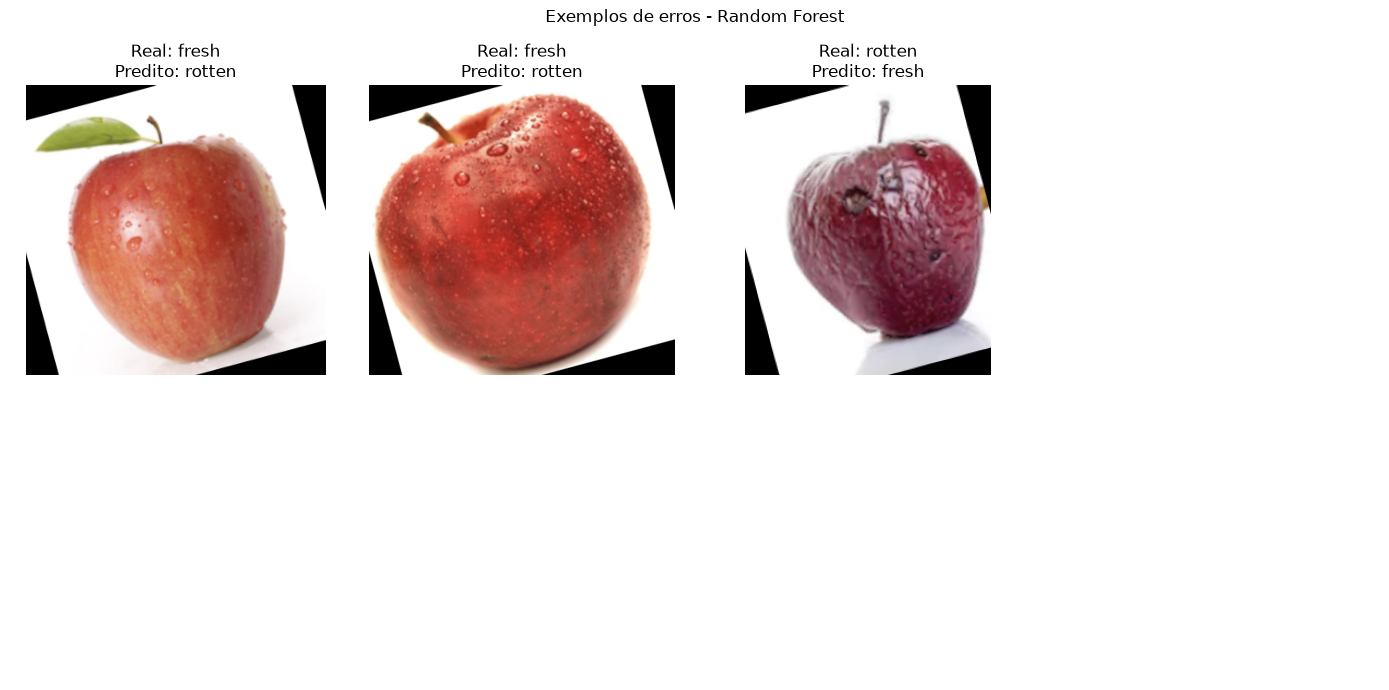

In [12]:
n_mostrar = min(8, len(erros_idx))

if n_mostrar > 0:
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    axes = axes.flatten()

    for ax, idx in zip(axes, erros_idx[:n_mostrar]):
        img = cv2.imread(paths_test[idx])
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        real = le.classes_[y_test[idx]]
        pred = le.classes_[y_pred_melhor[idx]]
        ax.imshow(img_rgb)
        ax.set_title(f"Real: {real}\nPredito: {pred}")
        ax.axis("off")

    for ax in axes[n_mostrar:]:
        ax.axis("off")

    plt.suptitle(f"Exemplos de erros - {melhor_modelo_nome}")
    plt.tight_layout()
    plt.savefig("../outputs/erros/exemplos_erros.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("Nenhum erro encontrado no conjunto de teste para este modelo.")

## 3.10 Discussao dos resultados e hipoteses sobre os erros

- Com o dataset real de macas, a separacao entre `fresh` e `rotten` continua boa, mas ja nao e artificialmente perfeita. Isso e positivo para a avaliacao, porque permite observar alguns erros e discutir suas causas.

- **Hipotese para os erros**: os erros tendem a ocorrer em imagens de fronteira, por exemplo macas frescas com sombras, reflexos, variacao natural de cor ou textura irregular, e macas podres cuja deterioracao e menos evidente ou ocupa uma regiao pequena. Nesses casos, features de cor (`mean_R`, `std_R`, `mean_V`) e textura (`glcm_contrast`, `glcm_homogeneity`, LBP) podem ficar proximas entre as duas classes.

- **Comparacao Random Forest vs SVM**: Random Forest tende a lidar bem com interacoes nao-lineares entre grupos de features (cor + textura + forma), alem de oferecer importancia de variaveis. O SVM tambem apresentou desempenho forte apos padronizacao com `StandardScaler` e ajuste de hiperparametros.

- A figura `outputs/erros/exemplos_erros.png` registra exemplos reais de classificacoes incorretas, permitindo analisar visualmente quais padroes confundiram o melhor modelo.



## 3.11 Conclusao: qual modelo escolher em producao?

A tabela comparativa final (`tabela_resultados`) resume acuracia, precisao, recall e F1 dos dois modelos no conjunto de teste.

**Criterio de escolha sugerido para este problema:**

- Em um cenario real de **triagem de frutas** (separar itens aptos de itens fora de padrao), o custo de um **falso negativo** (deixar passar uma fruta podre como fresca) tende a ser maior que o de um **falso positivo** (descartar uma fruta boa por engano). Por isso, o modelo com **maior recall para a classe `rotten`**, mantendo precisao aceitavel, e preferivel.

- Neste experimento com 300 imagens por classe, Random Forest e SVM apresentaram desempenho muito parecido. Quando isso acontece, a escolha pode considerar tambem:
  - **Custo computacional**: Random Forest costuma ser rapido e simples de re-treinar.
  - **Interpretabilidade**: Random Forest oferece importancia de variaveis nativa, util para explicar quais features influenciaram a classificacao.
  - **Estabilidade operacional**: modelos mais simples de monitorar e explicar tendem a ser melhores candidatos para um prototipo de inspecao visual.

**Escolha sugerida**: Random Forest, pelo desempenho equivalente ao SVM e pela interpretabilidade mais direta via importancia de features.

**Limitacoes**: o dataset tem fundo relativamente controlado e imagens ja bem centralizadas. Em uma esteira real, variacoes de iluminacao, angulo, sombra, oclusao e fundo podem reduzir a qualidade da segmentacao e das features.

**Melhorias futuras**: aumentar o dataset com fotos proprias, testar robustez com iluminacao diferente, ajustar a segmentacao para fundos mais complexos e comparar com tecnicas avancadas apenas como bonus (por exemplo transfer learning ou XAI).

